In [133]:
%md
# Analyse NTP logs
# Michael Camilleri
# May 2025

# Read the NTP logs and perform analysis and make offsets available

# loopstats


UsageError: Line magic function `%md` not found.


# Analyse NTP logs
Michael Camilleri
May 2025

Read the NTP logs and perform analysis and make offsets available

## loopstats
Read all loopstats files from the /etc folder. Resample at minute intervals with limited interpolation and output to a master Excel file with the 1 minute regular time series of offset and frequency


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime as dt
from datetime import time, timedelta
import os
import scipy

# Import the custom light curve functions 
# import importlib.util
# spec = importlib.util.spec_from_file_location("lc", "C:\\Users\\admin\\Occultations\\Camera Tests\\light_curves.py")
# lc = importlib.util.module_from_spec(spec)
# spec.loader.exec_module(lc)


C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\.libs\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [3]:
#pip install seaborn

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_theme()

In [4]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [140]:
file_path = 'C:/NTP/etc/'
file_path_output = 'C:\\Users\\admin\\Occultations\\'
files = os.listdir(file_path)
files = [s for s in files if "loopstats" in s and '.2025' in s]

In [246]:
import pandas as pd

import matplotlib.pyplot as plt

from datetime import datetime, timedelta

def mjd_to_date(mjd, seconds):
    """Convert Modified Julian Date and seconds past midnight to datetime."""
    jd = mjd + 2400000.5
    date = datetime(1858, 11, 17)  + timedelta(days=jd - 2400000.5)
    return date + timedelta(seconds=seconds)

def process_loopstats(file_path):
    """Process NTP loopstats logfile and return DataFrame with converted timestamps."""
    columns = ['MJD', 'Seconds', 'Offset', 'Frequency', 'Jitter', 'Stability', 'Interval']
    df = pd.read_csv(file_path, sep='\\s+', names=columns)

    # Convert MJD and Seconds to datetime
    df['Timestamp'] = df.apply(lambda row: mjd_to_date(row['MJD'], row['Seconds']), axis=1)

    # Drop MJD and Seconds columns
    df.drop(['MJD', 'Seconds'], axis=1, inplace=True)
    return df

def visualize_performance(df,metric='Offset',day=None, **kwargs):
    """Visualize time performance metrics (Offset and Frequency) over time."""
    if day is None:
        day = datetime(dt.today().date()     )
    if type(day) != list:
        day = [day,day+timedelta(days=1)]

    plt.figure(figsize=(12, 6))
    ax = plt.plot(df['Timestamp'], df[metric], label=metric)
    
    plt.xlim(day)

    if 'ylim' in kwargs:
        plt.ylim(kwargs.pop('ylim'))
    
    plt.title(f'{metric} Over Time')
    plt.xlabel('Timestamp')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

def generate_regular_timeseries(df, metric, freq='H', plot=False):

    """Generate regular time series from irregular data and plot it."""
    df.set_index('Timestamp', inplace=True)
#    regular_ts = df[metric].resample(freq).mean()
    regular_ts = pd.DataFrame([df[metric].resample(freq).min(),df[metric].resample(freq).max()]).mean(axis=0).fillna(method='ffill',limit=10).fillna(method='bfill',limit=10)
    if plot:
        plt.figure(figsize=(12, 6))
        plt.plot(regular_ts.index, regular_ts.values, label=f'Regular {metric} Time Series')
        plt.title(f'Regular {metric} Time Series')
        plt.xlabel('Timestamp')
        plt.ylabel(metric)
        plt.legend()
        plt.grid(True)
        plt.show()
    return(regular_ts)


In [249]:
# Process all Loopstats log files

rts_dict ={}
for i in files:
    print(i,end=', ')
    df = process_loopstats(file_path + i)
    #visualize_performance(df)
    offset_rts = generate_regular_timeseries(df.copy(), 'Offset','1min') *1000
    freq_rts = generate_regular_timeseries(df.copy(), 'Frequency','1min')
    jitter_rts = generate_regular_timeseries(df.copy(), 'Jitter','1min') *1000
    stability_rts = generate_regular_timeseries(df.copy(), 'Stability','1min')
    interval_rts = generate_regular_timeseries(df.copy(), 'Interval','1min')

    rts = pd.merge(pd.DataFrame(offset_rts,columns=['Offset']),pd.DataFrame(freq_rts,columns=['Frequency']),on='Timestamp')
    rts = pd.merge(rts,pd.DataFrame(jitter_rts,columns=['Jitter']),on='Timestamp')
    rts = pd.merge(rts,pd.DataFrame(stability_rts,columns=['Allan Deviation']),on='Timestamp')
    rts = pd.merge(rts,pd.DataFrame(interval_rts,columns=['Interval']),on='Timestamp')

    rts_dict[i] = rts.reset_index()

all_loopstats_rts=pd.concat(rts_dict).reset_index()[['Timestamp','Offset','Frequency','Jitter','Allan Deviation','Interval']]

# Generate regular time series for entire span 
regular_ts = all_loopstats_rts.copy()
all_loopstats_rts = pd.DataFrame(pd.date_range(start=regular_ts['Timestamp'].min(),end=regular_ts['Timestamp'].max(),freq='1min').values , columns = ['Timestamp'])
all_loopstats_rts = pd.merge(all_loopstats_rts,regular_ts, on='Timestamp',how='left')
all_loopstats_rts['Timestamp'].diff().unique()

all_loopstats_rts.head()
all_loopstats_rts.tail()
all_loopstats_rts.to_excel(file_path_output+"loopstats.xlsx",index=False)



loopstats.20250101, loopstats.20250102, loopstats.20250104, loopstats.20250105, loopstats.20250119, loopstats.20250123, loopstats.20250129, loopstats.20250130, loopstats.20250131, loopstats.20250201, loopstats.20250204, loopstats.20250205, loopstats.20250206, loopstats.20250207, loopstats.20250208, loopstats.20250211, loopstats.20250214, loopstats.20250215, loopstats.20250216, loopstats.20250217, loopstats.20250218, loopstats.20250219, loopstats.20250221, loopstats.20250223, loopstats.20250224, loopstats.20250225, loopstats.20250226, loopstats.20250227, loopstats.20250228, loopstats.20250302, loopstats.20250303, loopstats.20250304, loopstats.20250305, loopstats.20250306, loopstats.20250307, loopstats.20250308, loopstats.20250309, loopstats.20250310, loopstats.20250311, loopstats.20250312, loopstats.20250313, loopstats.20250314, loopstats.20250315, loopstats.20250316, loopstats.20250320, loopstats.20250321, loopstats.20250323, loopstats.20250326, loopstats.20250327, loopstats.20250328, 

<TimedeltaArray>
[NaT, '0 days 00:01:00']
Length: 2, dtype: timedelta64[ns]

,Timestamp,Offset,Frequency,Jitter,Allan Deviation,Interval
0,2025-01-01 00:04:00,0.0,428.955,0.000477,0.226777,6.0
1,2025-01-01 00:05:00,0.0,428.955,0.000477,0.226777,6.0
2,2025-01-01 00:06:00,0.0,428.955,0.000477,0.226777,6.0
3,2025-01-01 00:07:00,0.0,428.955,0.000477,0.226777,6.0
4,2025-01-01 00:08:00,0.0,428.955,0.000477,0.226777,6.0


,Timestamp,Offset,Frequency,Jitter,Allan Deviation,Interval
207346,2025-05-24 23:50:00,5.768209,-15.692,0.451350,0.107301,6.0
207347,2025-05-24 23:51:00,5.768209,-15.692,0.451350,0.107301,6.0
207348,2025-05-24 23:52:00,5.768209,-15.692,0.451350,0.107301,6.0
207349,2025-05-24 23:53:00,5.768209,-15.692,0.451350,0.107301,6.0
207350,2025-05-24 23:54:00,5.560432,-15.605,0.428542,0.104927,6.0


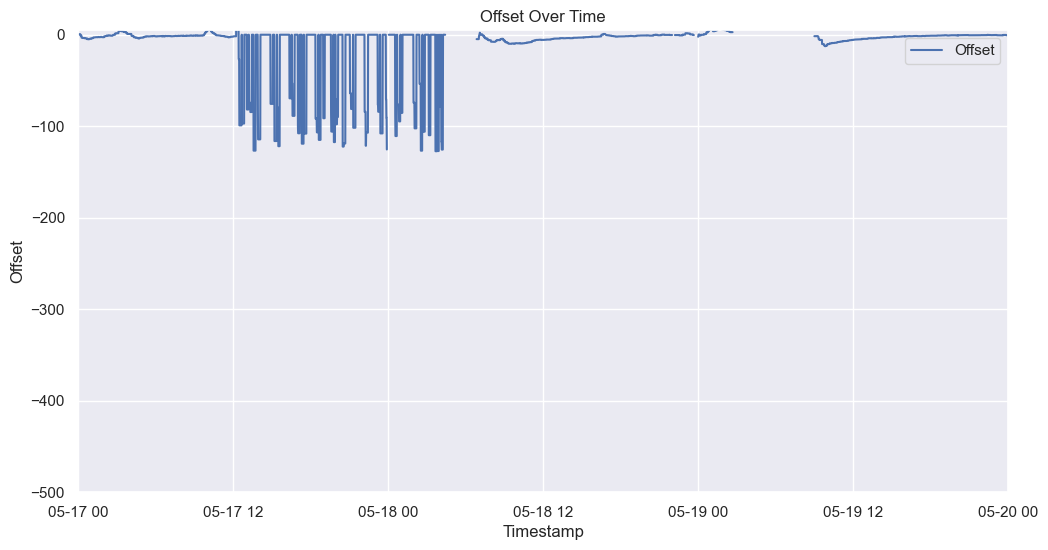

In [254]:
visualize_performance(all_loopstats_rts,'Offset',[datetime(2025,5,17),datetime(2025,5,20)],ylim=[-500,5])



In [17]:
def read_ntp_peerstats(path, file):
    data = pd.read_csv(file_path +'/'+file,delimiter = ' ',header=None)
    
    data.columns = ['MJD','sec_frac','address','status','offset','delay','dispersion','jitter']
    date = file.split('.')[1]
    date
    data['Date'] = dt.strptime(date,'%Y%m%d') 
    data['Time'] = [dt.strptime(date,'%Y%m%d') + timedelta(seconds =i) for i in data['Seconds since midnight'] ]
    data['Time Rounded'] = [dt.strptime(date,'%Y%m%d') + timedelta(minutes =round(i/60)) for i in data['Seconds since midnight'] ]
    data
    data['Offset (ms)'] = data['Offset (ms)']*1000 
    data = data[['Date','Time','Offset (ms)','Frequency (ppm)','Jitter','PPS Jitter','Stations','Time Rounded']]
    data['Source file'] = file_path +'/'+file
    return data
allntp = {}
#pd.DataFrame()
for i in files:
    print(i,end=', ')
    data = read_ntp(file_path,i)
    allntp[i] = data
    #pd.concat([allntp,data])

allntp = pd.concat(allntp)
allntp.sort_values('Time',inplace=True)

ValueError: No objects to concatenate

In [20]:
files = os.listdir(file_path)
files = [s for s in files if "peerstats" in s and '.20' in s]
files

['peerstats.20250523']

peerstats.20250523, C:\Users\admin\Occultations\20250518 NTP tests\NTP test NZ servers\


address
103.158.134.33    Axes(0.125,0.2;0.775x0.68)
103.242.68.68     Axes(0.125,0.2;0.775x0.68)
103.242.70.4      Axes(0.125,0.2;0.775x0.68)
161.65.172.9      Axes(0.125,0.2;0.775x0.68)
202.21.136.135    Axes(0.125,0.2;0.775x0.68)
202.46.177.18     Axes(0.125,0.2;0.775x0.68)
202.46.178.18     Axes(0.125,0.2;0.775x0.68)
43.252.70.34      Axes(0.125,0.2;0.775x0.68)
dtype: object

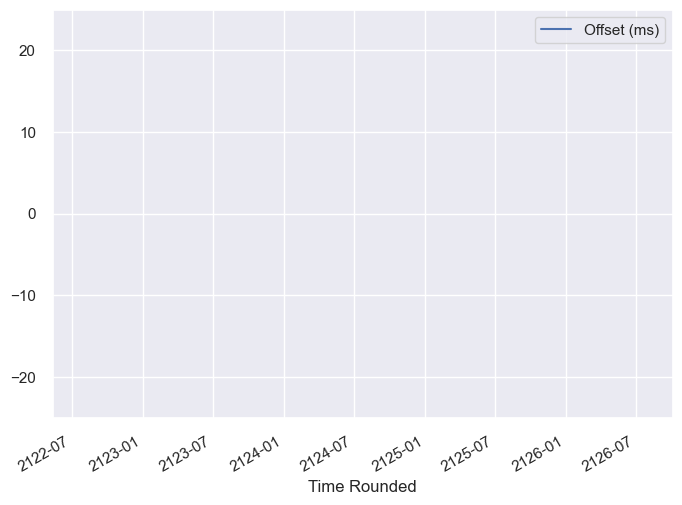

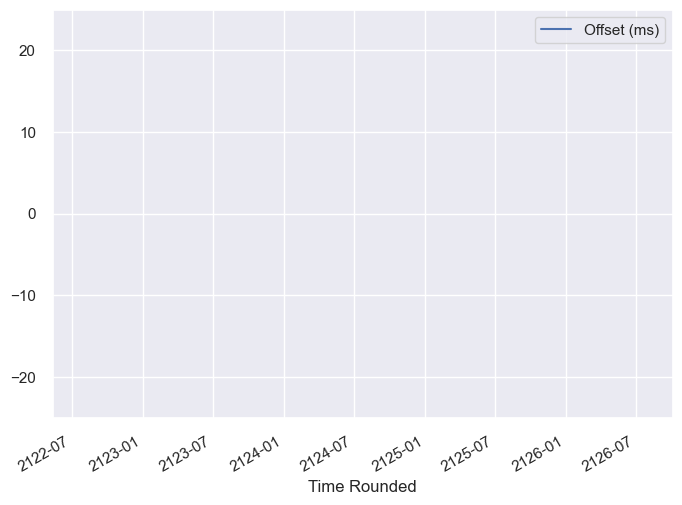

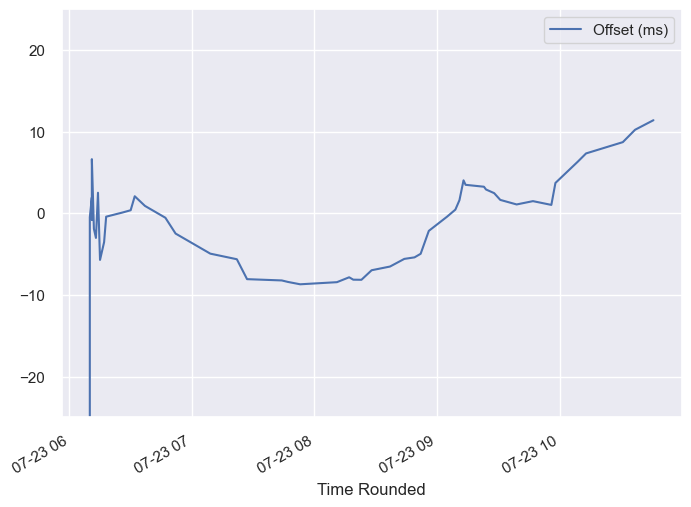

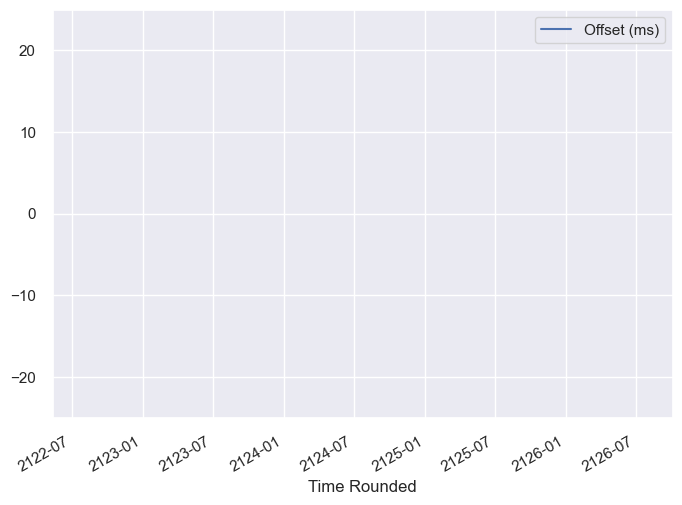

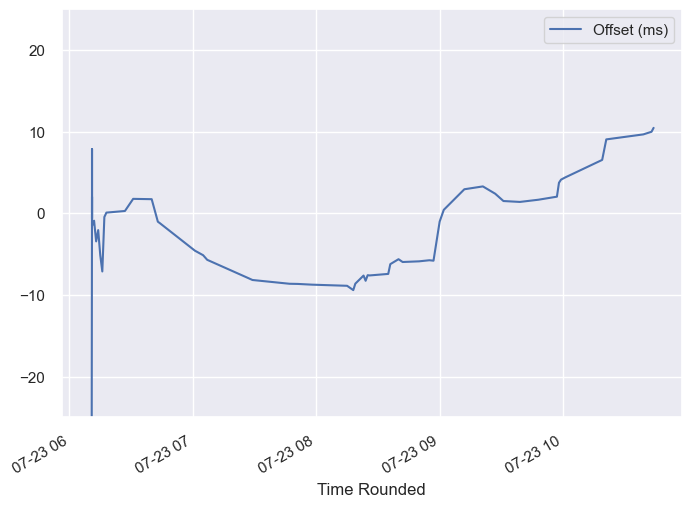

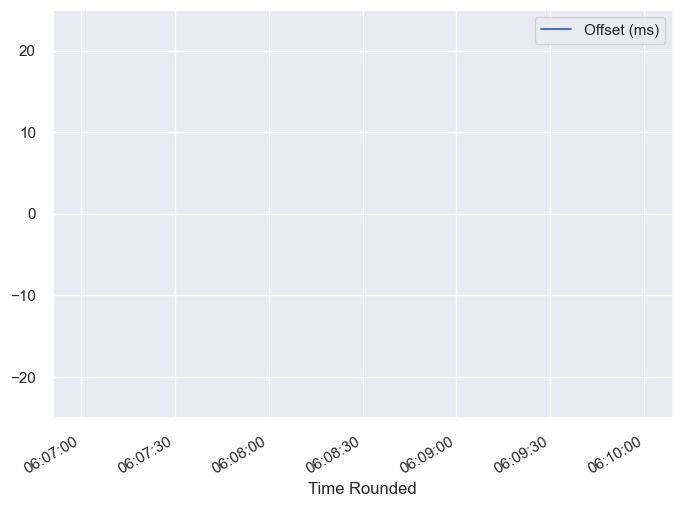

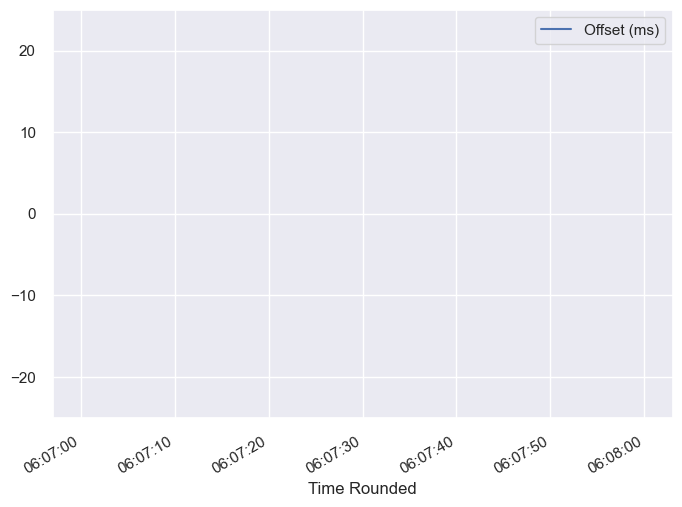

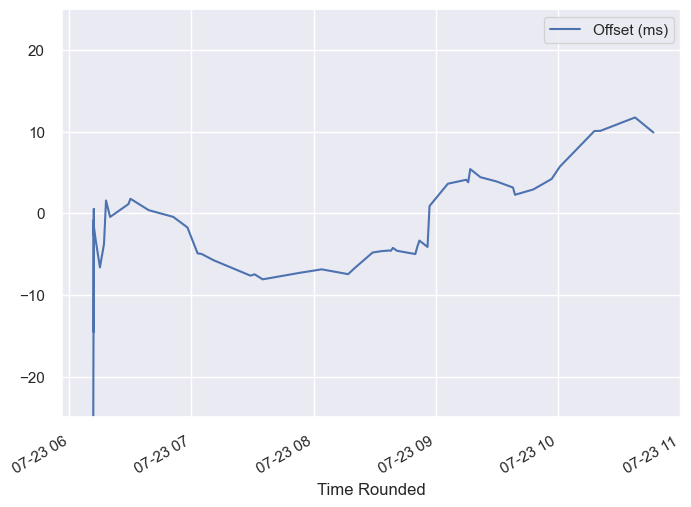

In [25]:
def read_ntp_peerstats(file_path, file):
    data = pd.read_csv(file_path +file,delimiter = ' ',header=None)
    data.columns = ['MJD','sec_frac','address','status','Offset (ms)','delay','dispersion','jitter']
# Convert from Modified Julian Date
    data['Date'] = [dt.strptime('1958-11-17','%Y-%M-%d') + timedelta(days=i) for i in data['MJD']]
    data['Time'] = [timedelta(seconds =float(i)) for i in data['sec_frac'] ]
    data['Time'] = data['Date'] + data['Time']
    data['Time Rounded'] = [timedelta(minutes =round(i/60)) for i in data['sec_frac'] ]
    data['Time Rounded'] = data['Date'] + data['Time Rounded']
    data
    data['Offset (ms)'] = data['Offset (ms)']*1000 
    data['delay'] = data['delay']*1000 
    data['dispersion'] = data['dispersion']*1000 
    data['jitter'] = data['jitter']*1000 
    data = data[['Date','Time','address','Offset (ms)','delay','dispersion','jitter','Time Rounded']]
    data['Source file'] = file_path +'/'+file
    return data
all_peerstats = {}
#pd.DataFrame()

for i in files:
    print(i,end=', ')
    print(file_path)
    data = read_ntp_peerstats(file_path,i)
    all_peerstats[i] = data
    #pd.concat([all_peerstats,data])

all_peerstats = pd.concat(all_peerstats)
all_peerstats.sort_values('Time',inplace=True)
all_peerstats.groupby('address').plot('Time Rounded','Offset (ms)',kind='line',ylim=[-25,25])
##all_peerstats.where(all_peerstats.address == '127.127.20.4').plot('Time Rounded','Offset (ms)',kind='line',title= 'GPS PPS Offset when Unselected')

#all_peerstats.where(all_peerstats.address == '161.65.172.9').plot('Time Rounded','Offset (ms)',kind='line',title= 'Offset to Measurement Standards Lab',ylim=[-15,10])
#all_peerstats.where(all_peerstats.address == '161.65.172.9').plot('Time Rounded','delay',kind='line',title= 'Delay to Measurement Standards Lab',ylim=[0,20])
#all_peerstats.where(all_peerstats.address == '161.65.172.9').plot('Time Rounded','Offset (ms)',kind='line',title= 'Offset to Measurement Standards Lab')
#all_peerstats.where(all_peerstats.address == '161.65.172.9').plot('Time Rounded','delay',kind='line',title= 'Delay to Measurement Standards Lab')



In [22]:
allntp.plot('Time Rounded','Offset (ms)')
#allntp['Offset (ms)'].hist()

AttributeError: 'dict' object has no attribute 'plot'

<Axes: xlabel='Time Rounded'>

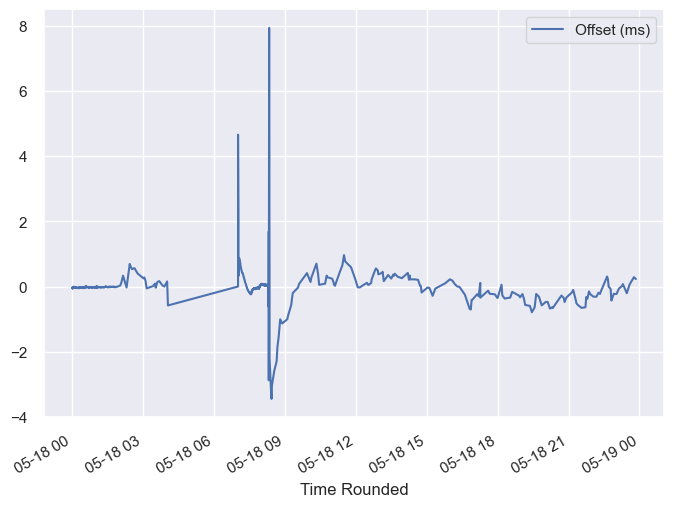

In [12]:
timecheck = (dt.strptime("20250518",'%Y%m%d'))

sameday = allntp[allntp.Date ==timecheck]
sameday.plot('Time Rounded','Offset (ms)')

mins = [timecheck + timedelta(seconds = i) for i in range(0,86440,60)]
allday = pd.DataFrame(mins,columns =['Minutes'])
allday = pd.merge(allday,sameday,left_on='Minutes',right_on ='Time Rounded',how='left')

In [13]:
allday.set_index('Minutes')
allday.interpolate(method='linear',inplace=True)

,Date,Time,Offset (ms),Frequency (ppm),Jitter,PPS Jitter,Stations,Time Rounded,Source file
Minutes,,,,,,,,,
2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:05.564,-0.044877,21.824,0.000006,0.001374,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:13.554,-0.051454,21.822,0.000006,0.001400,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:21.554,-0.041139,21.821,0.000007,0.001383,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:29.551,-0.055132,21.819,0.000008,0.001423,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
2025-05-18 00:01:00,2025-05-18,2025-05-18 00:00:37.558,-0.050999,21.817,0.000008,0.001441,3.0,2025-05-18 00:01:00,C:\Users\admin\Occultations\20250518 NTP tests...
...,...,...,...,...,...,...,...,...,...
2025-05-18 23:56:00,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN
2025-05-18 23:57:00,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN
2025-05-18 23:58:00,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN


In [14]:
allday.head()
allday.tail()

,Minutes,Date,Time,Offset (ms),Frequency (ppm),Jitter,PPS Jitter,Stations,Time Rounded,Source file
0,2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:05.564,-0.044877,21.824,0.000006,0.001374,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
1,2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:13.554,-0.051454,21.822,0.000006,0.001400,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
2,2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:21.554,-0.041139,21.821,0.000007,0.001383,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
3,2025-05-18 00:00:00,2025-05-18,2025-05-18 00:00:29.551,-0.055132,21.819,0.000008,0.001423,3.0,2025-05-18 00:00:00,C:\Users\admin\Occultations\20250518 NTP tests...
4,2025-05-18 00:01:00,2025-05-18,2025-05-18 00:00:37.558,-0.050999,21.817,0.000008,0.001441,3.0,2025-05-18 00:01:00,C:\Users\admin\Occultations\20250518 NTP tests...


,Minutes,Date,Time,Offset (ms),Frequency (ppm),Jitter,PPS Jitter,Stations,Time Rounded,Source file
1960,2025-05-18 23:56:00,2025-05-18,2025-05-18 23:50:33.703000064,0.230063,21.291,0.000181,0.001533,7.0,2025-05-18 23:51:00,NaN
1961,2025-05-18 23:57:00,2025-05-18,2025-05-18 23:50:33.703000064,0.230063,21.291,0.000181,0.001533,7.0,2025-05-18 23:51:00,NaN
1962,2025-05-18 23:58:00,2025-05-18,2025-05-18 23:50:33.703000064,0.230063,21.291,0.000181,0.001533,7.0,2025-05-18 23:51:00,NaN
1963,2025-05-18 23:59:00,2025-05-18,2025-05-18 23:50:33.703000064,0.230063,21.291,0.000181,0.001533,7.0,2025-05-18 23:51:00,NaN
1964,2025-05-19 00:00:00,2025-05-18,2025-05-18 23:50:33.703000064,0.230063,21.291,0.000181,0.001533,7.0,2025-05-18 23:51:00,NaN


In [15]:
allday.shape

(1965, 10)

<Axes: title={'center': 'NTP Offset'}, xlabel='MM-DD Hour'>

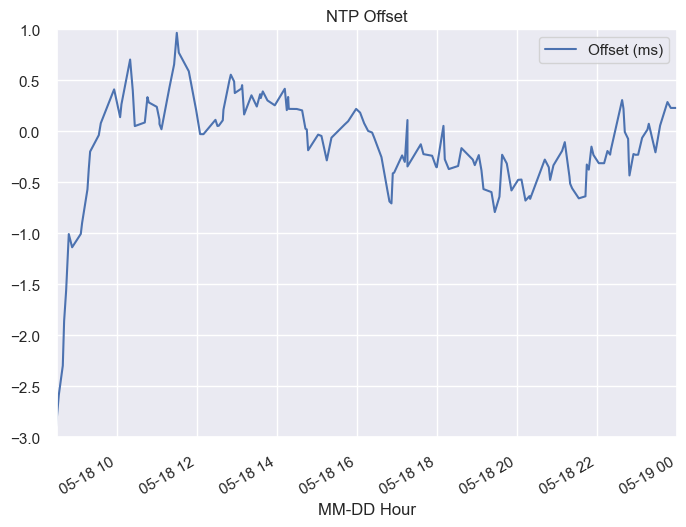

In [38]:
allday.plot('Minutes','Offset (ms)',xlim=[dt.strptime("20250518 08:30:00",'%Y%m%d %H:%M:%S'),dt.strptime("20250519",'%Y%m%d')],ylim=[-3,1],title="NTP Offset",xlabel='MM-DD Hour')

In [17]:
import pickle
ff = open('ntp_offsets','wb')
pickle.dump(allday,ff)
ff.close()

In [141]:
pd.read_csv(r'C:\Program Files (x86)\VisualGPS\NMEATime2\gpslog.txt',delimiter='\t')

,"$GNGGA,060318.000,3650.1263,S,17439.4673,E,2,39,0.42,26.8,M,26.4,M,,*58"
0,"$GNGSA,A,3,04,09,16,27,08,07,194,26,03,31,,,0...."
1,"$GNGSA,A,3,71,73,74,72,80,82,,,,,,,0.77,0.42,0..."
2,"$GNGSA,A,3,07,27,30,08,21,,,,,,,,0.77,0.42,0.6..."
3,"$GNGSA,A,3,37,20,32,04,23,01,59,39,08,13,16,38..."
4,"$GNGSA,A,3,46,43,06,28,19,11,,,,,,,0.77,0.42,0..."
...,...
61711,"$GNGSA,A,3,72,73,,,,,,,,,,,0.96,0.47,0.84,2*03"
61712,"$GNGSA,A,3,27,21,19,15,07,30,,,,,,,0.96,0.47,0..."
61713,"$GNGSA,A,3,46,37,28,39,27,16,59,06,19,20,09,30..."
61714,"$GNGSA,A,3,23,,,,,,,,,,,,0.96,0.47,0.84,4*05"
